<a href="https://colab.research.google.com/github/PaoloDes04/URL-Phishing-Detection-ML/blob/main/esame_phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# 1. Caricamento del dataset di Kaggle
dataset = pd.read_csv('Phishing_Legitimate_full.csv')

# 2. Pulizia dei dati rimuovo la colonna id
if 'id' in dataset.columns:
    dataset.drop('id', axis=1, inplace=True)

# Il dataset di Kaggle chiama la variabile di output 'CLASS_LABEL'
# La rinominiamo in 'target'
if 'CLASS_LABEL' in dataset.columns:
    dataset.rename(columns={'CLASS_LABEL': 'target'}, inplace=True)

# 3. Separazione delle feature (X) dalla variabile target (y)
X = dataset.drop('target', axis=1).values
y = dataset['target'].values

# 4. Suddivisione in Training Set (80%) e Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print(f"Campioni usati per l'addestramento: {len(X_train)}")
print(f"Campioni usati per il test: {len(X_test)}")

Campioni usati per l'addestramento: 8000
Campioni usati per il test: 2000


In [ ]:
# Configuriamo l'ensamble con 50 alberi
rfc = RandomForestClassifier(n_estimators=50, random_state=0)

# 2. Addestramento del modello fornendo i dati di training
rfc.fit(X_train, y_train)

# 3. Calcolo e stampa dell'accuratezza globale sul set di test
accuracy = rfc.score(X_test, y_test) * 100
print(f"Accuratezza del modello: {accuracy:.2f}%")

Accuratezza del modello: 97.80%


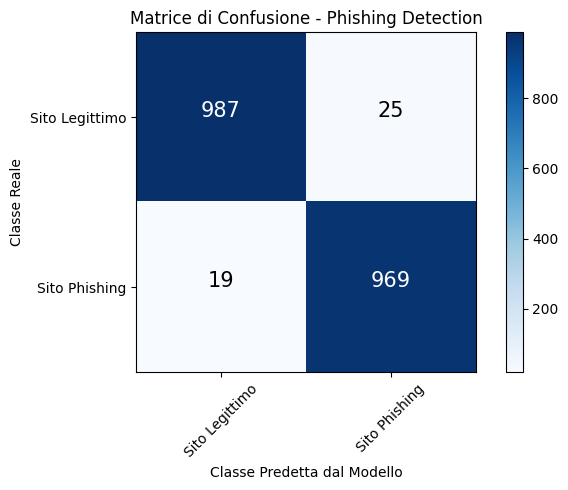

In [ ]:
# 1. Effettuiamo le predizioni sui dati di test
y_pred = rfc.predict(X_test)

# 2. Generiamo la matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# 3. Disegniamo il grafico (Stile fedele alle slide del corso)
plt.figure(figsize=(7, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matrice di Confusione - Phishing Detection')
plt.colorbar()

# Configurazione delle etichette (0 = Legittimo, 1 = Phishing)
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Sito Legittimo', 'Sito Phishing'], rotation=45)
plt.yticks(tick_marks, ['Sito Legittimo', 'Sito Phishing'])

plt.xlabel('Classe Predetta dal Modello')
plt.ylabel('Classe Reale')

# Inserimento dei valori all'interno della griglia
fnt = 15
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > cm.max() / 2. else "black",
             fontsize=fnt)

plt.tight_layout()
plt.show()

In [ ]:
# Installiamo la libreria per l'interfaccia grafica
!pip install gradio -q

import gradio as gr
import random

# Liste di URL simulati AMPLIATE per rendere l'interfaccia molto più realistica e varia
url_phishing_mock = [
    "http://secure-update-paypal-account.info/login.php",
    "http://192.168.1.105/banca-intesa/verifica-dati",
    "http://facebook-security-check-alert.com/auth",
    "https://amazon-prime-billing-error-it.net/refund",
    "http://poste-italiane-sicurezza-conto.com/login",
    "http://www.apple-id-verification-support.net/auth",
    "http://netflix-billing-update-failed.info/payment",
    "http://192.168.0.55/unicredit/sblocco-carta",
    "http://supporto-aruba-rinnovo-dominio.com/auth",
    "http://instagram-verify-blue-badge.net/login",
    "http://microsoft-office365-login-update.com/admin",
    "http://fedex-tracking-delivery-failed.net/track",
    "http://dhl-spedizione-in-giacenza.info/pay-customs",
    "http://secure-login-bper-banca.eu/verifica",
    "http://webmail-upgrade-storage-quota.com/login"
]

url_legittimi_mock = [
    "https://www.paypal.com/it/signin",
    "https://www.intesasanpaolo.com/it/personale.html",
    "https://www.facebook.com/login",
    "https://www.amazon.it/gp/yourstore/home",
    "https://www.poste.it/",
    "https://appleid.apple.com/it/",
    "https://www.netflix.com/it/login",
    "https://www.unicredit.it/it/privati.html",
    "https://manage.aruba.it/login",
    "https://www.instagram.com/",
    "https://login.microsoftonline.com/",
    "https://www.fedex.com/it-it/tracking.html",
    "https://www.dhl.com/it-it/home/tracciabilita.html",
    "https://www.bper.it/privati",
    "https://mail.google.com/"
]

def analizza_url_casuale():
    # 1. Peschiamo un campione a caso dal test set
    idx = random.randint(0, len(X_test) - 1)
    campione = X_test[idx].reshape(1, -1)
    classe_reale = y_test[idx]

    # 2. Assegniamo un URL testuale finto ma realistico in base alla classe reale
    if classe_reale == 1:
        url_mostrato = random.choice(url_phishing_mock)
    else:
        url_mostrato = random.choice(url_legittimi_mock)

    # 3. Estraiamo l'Identikit dell'URL (le feature matematiche)
    nomi_colonne = dataset.drop('target', axis=1).columns
    dettagli_struttura = "🔍 DATI MATEMATICI ESTRATTI DALLA STRUTTURA DELL'URL:\n"
    dettagli_struttura += "-" * 50 + "\n"

    # Mostriamo alcune feature per far capire come ragiona il modello
    for i in range(6):
        nome_feature = nomi_colonne[i]
        valore_feature = campione[0][i]
        dettagli_struttura += f"▶ {nome_feature}: {valore_feature}\n"

    dettagli_struttura += "\n*(Queste sono le feature numeriche lette dall'IA)*"

    # 4. Il modello fa la predizione sui numeri
    predizione = rfc.predict(campione)[0]
    probabilita = rfc.predict_proba(campione)[0]

    # 5. Creiamo la grafica accattivante
    if predizione == 1:
        esito_html = "<h1 style='color:#D32F2F; text-align:center;'>🚨 MINACCIA RILEVATA: PHISHING! 🚨</h1>"
        dettagli = f"⚠️ L'Intelligenza Artificiale è sicura al {probabilita[1]*100:.1f}% che questo URL sia una TRUFFA."
    else:
        esito_html = "<h1 style='color:#388E3C; text-align:center;'>✅ SITO SICURO ✅</h1>"
        dettagli = f"🛡️ L'Intelligenza Artificiale è sicura al {probabilita[0]*100:.1f}% che questo URL sia LEGITTIMO."

    reale = "Phishing" if classe_reale == 1 else "Sito Sicuro"
    info_tecniche = f"Realtà dei fatti (dal dataset originale): Era un {reale}"

    return url_mostrato, dettagli_struttura, esito_html, dettagli, info_tecniche

# --- CREAZIONE DELL'INTERFACCIA GRAFICA ---
with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown("<h1 style='text-align:center;'>🛡️ Radar Sicurezza IA: Rilevatore di Phishing</h1>")
    gr.Markdown("<p style='text-align:center;'>Simulazione di un firewall intelligente basato su Random Forest.</p>")

    with gr.Row():
        btn_analizza = gr.Button("🔍 Intercetta e Analizza Nuovo URL", variant="primary")

    # OUTPUTS DELL'INTERFACCIA
    out_url = gr.Textbox(label="🌐 Stringa URL Intercettata dal Traffico (Simulazione)", lines=1)
    out_struttura = gr.Textbox(label="⚙️ Identikit Strutturale (Feature Vector analizzato dall'IA)", lines=9)
    out_esito = gr.HTML()
    out_dettagli = gr.Textbox(label="📊 Report dell'Analisi IA")
    out_reale = gr.Textbox(label="✅ Verifica Tecnica (Ground Truth)")

    # Colleghiamo il pulsante e tutti gli output (ora sono 5)
    btn_analizza.click(fn=analizza_url_casuale, inputs=None, outputs=[out_url, out_struttura, out_esito, out_dettagli, out_reale])

# Lanciamo l'app!
app.launch(share=True)

/tmp/ipykernel_11825/1854921635.py:87: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://80b0fbcc37b645240c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
